In [2]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer



import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


#### Get Dataset

In [3]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys() 

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
# Extract Data
X, y = mnist.data, mnist.target
print('X shape: ',X.shape, ' y Shape: ', y.shape)
print('X contains 28x28 pixal image. Where y Contains digital o/p i.e number 0 to 9')

X shape:  (70000, 784)  y Shape:  (70000,)
X contains 28x28 pixal image. Where y Contains digital o/p i.e number 0 to 9


#### Matplot Lib for Image

In [5]:
def plot_digit(image_data,pixel_hight,pixel_width):
    image = image_data.reshape(pixel_hight, pixel_width)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

Actual val:  2


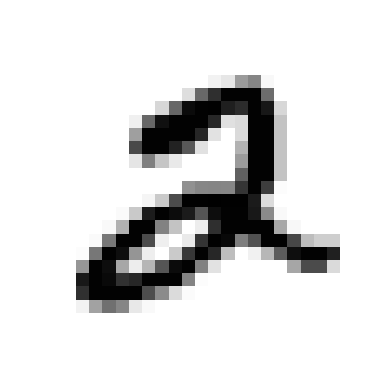

In [6]:
# Draw Some image
pos = 5
Digits = X[pos]
ActualVal = y[pos]
plot_digit(image_data = Digits,pixel_hight = 28 ,pixel_width = 28)
print("Actual val: ",ActualVal)

In [7]:
# Get Traning & Test Data
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


In [8]:
# Create models
models = SGDClassifier(random_state=42)
sgd_clf = models.fit(X_train, y_train)

In [9]:
X_test.shape, y_test.shape

((10000, 784), (10000,))

In [10]:
# Get some predictions
pos = np.random.randint(0+6000,10+6000,5)
predicted_output = sgd_clf.predict(X_test[pos])
print('Predicted output: ',predicted_output)
print(' Actrual output : ',y_test[pos])
print('Corrected result: ',predicted_output == y_test[pos])

Predicted output:  ['1' '1' '3' '7' '0']
 Actrual output :  ['1' '1' '3' '7' '0']
Corrected result:  [ True  True  True  True  True]


### Performance Measures

#### Measuring Accuracy Using Cross-Validation

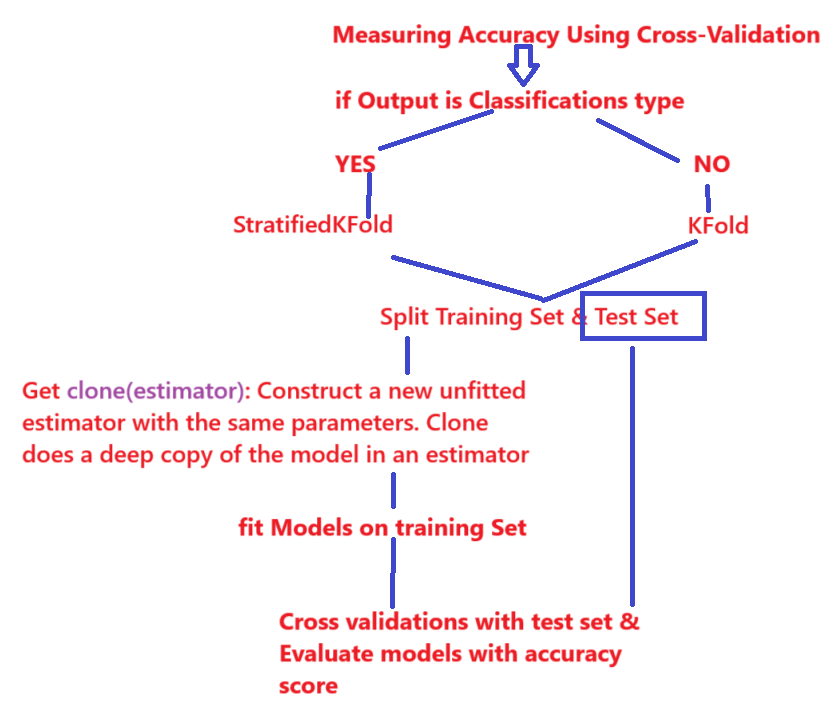

In [12]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [13]:
# Cross validations Manually
skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [ ]:
# By using crass validations

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])